In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import os

In [2]:
os.listdir("../..")

['.claude',
 '.env',
 '.git',
 '.gitignore',
 'data',
 'datetime_test.py',
 'LICENSE',
 'Notebook.ipynb',
 'README.md',
 'requiremets.txt',
 'src']

In [3]:
x = pd.read_csv('../../data/weather/multi_region_weather_data.csv')
y = pd.read_csv('../../data/energy/eia_data_SUN.csv')

In [4]:
y_array = y['value'].to_numpy()
y_array


array([12367,  7740,  1128, ..., 20463, 18919, 17372], shape=(14065,))

In [5]:
X = x.drop(columns="time").to_numpy()

In [6]:
n = int(len(X) * 0.7)
X_train, X_test = X[:n], X[n:]
y_train, y_test = y_array[:n], y_array[n:]

In [7]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

In [8]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (9845, 24), y_train shape: (9845,)
X_test shape: (4220, 24), y_test shape: (4220,)


In [9]:
reg = LinearRegression().fit(X_train, y_train)
print(reg.score(X_test, y_test))
print(reg.coef_)
print(reg.intercept_)

0.9276532539528279
[150.04473264  17.10939457   3.60531591 -18.78699887  -0.81322213
   7.71624594   1.8882179   17.47359307  61.46024346  -8.95083908
  -2.93307654  53.74280842   2.752878   -14.02563261  10.76420934
  18.99486918 -75.61699639  -7.48932737  -0.59558228  24.0194358
   2.78484018   7.82799848  -0.25974087  -4.66950362]
-3646.555650253513


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

<Axes: title={'center': 'CAISO solar, last 48 hours'}, xlabel='time', ylabel='MWh'>

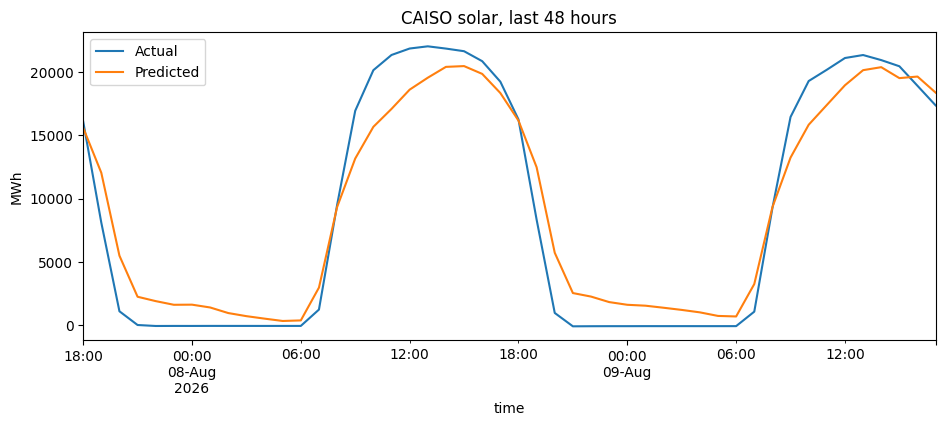

In [11]:
results = pd.DataFrame(
    {"Actual": y_test, "Predicted": reg.predict(X_test)},
    index=pd.to_datetime(x["time"], utc=True).iloc[-len(y_test):]
            .dt.tz_convert("America/Los_Angeles").dt.tz_localize(None),
)
results.tail(48).plot(figsize=(11, 4), ylabel="MWh", title="CAISO solar, last 48 hours")

In [12]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/48.9 MB 5.8 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/48.9 MB 5.9 MB/s eta 0:00:08
   --- ------------------------------------ 3.9/48.9 MB 6.0 MB/s eta 0:00:08
   ---- ----------------------------------- 5.2/48.9 MB 5.8 MB/s eta 0:00:08
   ----- ---------------------------------- 6.3/48.9 MB 6.0 MB/s eta 0:00:08
   ------ --------------------------------- 7.6/48.9 MB 5.8 MB/s eta 0:00:08
   ------- -------------------------------- 8.7/48.9 MB 5.8 MB/s eta 0:00:07
   ------- -------------------------------- 9.7/48.9 MB 5.6 MB/s eta 0:00:07
   -------- ------------------------------- 11.0/48.9 MB 5.7 MB/s eta 0:00:07
   ---------- ----------------------------- 12.3/48.9 MB 5.7 MB/s eta 0:00:07
   -------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\claud\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
from xgboost import XGBRegressor

# Validation slice carved off the END of train, for early stopping.
# It must be chronological, and must NOT be X_test — stopping on test is leakage.
v = int(len(X_train) * 0.85)
X_fit, X_val = X_train[:v], X_train[v:]
y_fit, y_val = y_train[:v], y_train[v:]

model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric="mae",
    random_state=42,     # controls subsampling only — NOT the split
)
model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,'mae'


<Axes: title={'center': 'CAISO solar, last 48 hours'}, xlabel='time', ylabel='MWh'>

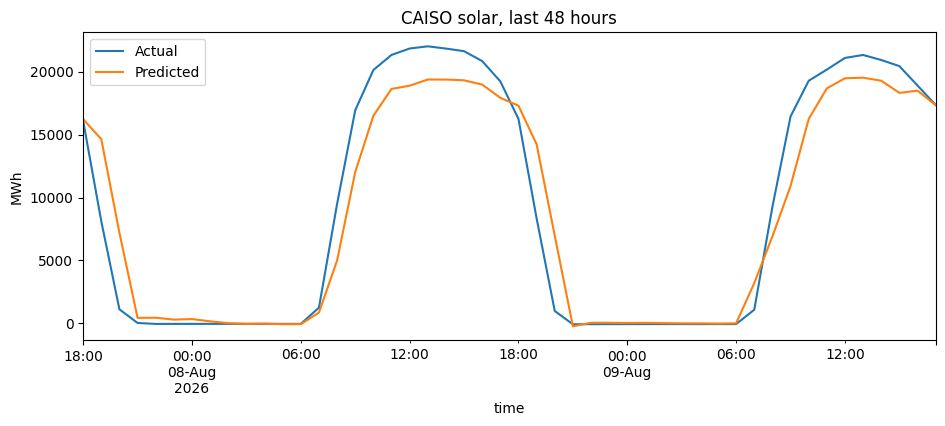

In [14]:
results2 = pd.DataFrame(
    {"Actual": y_test, "Predicted": model.predict(X_test)},
    index=pd.to_datetime(x["time"], utc=True).iloc[-len(y_test):]
            .dt.tz_convert("America/Los_Angeles").dt.tz_localize(None),
)
results2.tail(48).plot(figsize=(11, 4), ylabel="MWh", title="CAISO solar, last 48 hours")

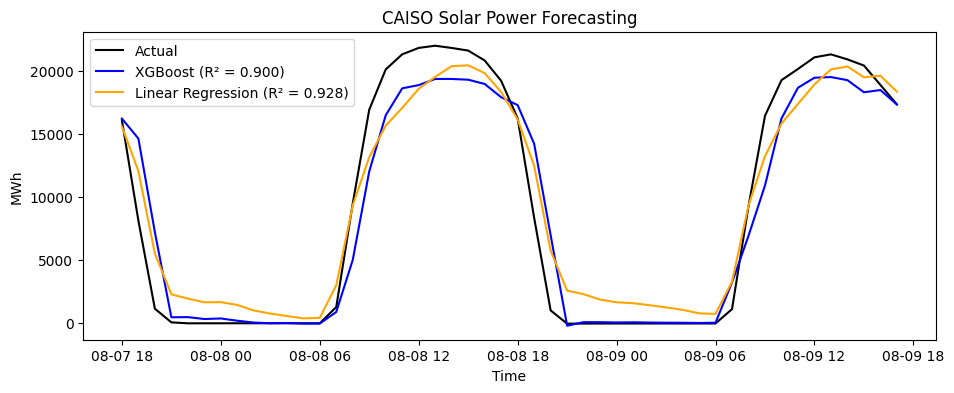

In [15]:
from sklearn.metrics import r2_score

# Full test set (4220 hours) -- the model's actual score, not the 48h window
r2_lin = r2_score(results["Actual"],  results["Predicted"])
r2_xgb = r2_score(results2["Actual"], results2["Predicted"])

skresults = results.tail(48)
xgresults = results2.tail(48)

plt.figure(figsize=(11, 4))
plt.plot(skresults.index, skresults["Actual"], label="Actual", color="black")
plt.plot(xgresults.index, xgresults["Predicted"], label=f"XGBoost (R² = {r2_xgb:.3f})", color="blue")
plt.plot(skresults.index, skresults["Predicted"], label=f"Linear Regression (R² = {r2_lin:.3f})", color="orange")
plt.xlabel("Time")
plt.ylabel("MWh")
plt.title("CAISO Solar Power Forecasting")
plt.legend()
plt.show()

BAT
Linear Regression    MAE   7729.8   R² -0.8591
XGBoost              MAE   7724.7   R² -0.8588


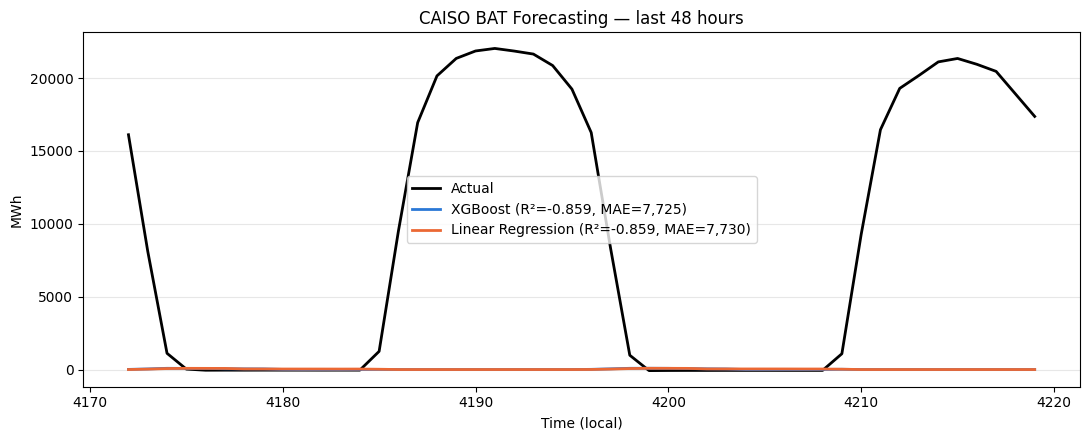

COL


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor


def load_data(energy_source):
    x = pd.read_csv('../../data/weather/multi_region_weather_data.csv', parse_dates=['time'])
    y = pd.read_csv(f'../../data/energy/eia_data_{energy_source}.csv', parse_dates=['period'])
    return x, y

def convert_to_usable_arrays(x,y):
    local = x["time"].dt.tz_convert("America/Los_Angeles")
    features = x.drop(columns="time").copy()
    features["hour"] = local.dt.hour
    features["month"] = local.dt.month
    X_np = features.to_numpy()
    Y_np = y["value"].fillna(0).to_numpy()  # Fill NaN values with 0
    return X_np, Y_np

def split_data(X, y_array):
    n = int(len(X) * 0.7)
    X_train, X_test = X[:n], X[n:]
    y_train, y_test = y_array[:n], y_array[n:]
    return X_train, X_test, y_train, y_test

def train_linear_regression(energy_source):
    x, y = load_data(energy_source)
    X, y_array = convert_to_usable_arrays(x, y)
    X_train, X_test, y_train, y_test = split_data(X, y_array)
    reg =LinearRegression().fit(X_train, y_train)
    return reg, X_test, y_test

def train_xgboost(energy_source):
    x, y = load_data(energy_source)
    X, y_array = convert_to_usable_arrays(x, y)
    X_train, X_test, y_train, y_test = split_data(X, y_array)
    v = int(len(X_train) * 0.85)
    X_fit, X_val = X_train[:v], X_train[v:]
    y_fit, y_val = y_train[:v], y_train[v:]

    grid = {
    "n_estimators":     [200, 400, 800],
    "learning_rate":    [0.03, 0.05, 0.1],
    "max_depth":        [3, 4, 6, 8],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "reg_lambda":       [1, 5, 20],
    }
   
    search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1),
    grid, n_iter=30,
    cv=TimeSeriesSplit(n_splits=4),
    scoring="neg_mean_absolute_error",
    random_state=42, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    
    return (search.score(X_test, y_test),search.best_params_, search.best_estimator_ )


for energy_source in ['BAT' ,'COL', 'GEO', 'NG', 'NUC', 'OIL', 'OTH', 'PS', 'SNB', 'SUN', 'WAT', 'WND']:
    print(energy_source)
    reg, X_test, Y_test = train_linear_regression(energy_source)
    _, _, model =train_xgboost(energy_source)
    preds = {
    "Linear Regression": np.clip(reg.predict(X_test), 0, None),
    "XGBoost":           np.clip(model.predict(X_test), 0, None),
    }

    results = pd.DataFrame({"Actual": y_test, **preds})

    scores = {k: (mean_absolute_error(y_test, p), r2_score(y_test, p))
            for k, p in preds.items()}
    for name, (mae, r2) in scores.items():
        print(f"{name:20s} MAE {mae:8.1f}   R² {r2:.4f}")

    # ---------- 7. plot ----------
    window = results.tail(48)

    plt.figure(figsize=(11, 4.5))
    plt.plot(window.index, window["Actual"], label="Actual", color="black", lw=2)
    for name, color in [("XGBoost", "#2a78d6"), ("Linear Regression", "#eb6834")]:
        mae, r2 = scores[name]
        plt.plot(window.index, window[name], color=color, lw=2,
                label=f"{name} (R²={r2:.3f}, MAE={mae:,.0f})")

    plt.xlabel("Time (local)")
    plt.ylabel("MWh")
    plt.title(f"CAISO {energy_source} Forecasting — last 48 hours")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# ---------- 6. results ----------
# clip at 0 -- generation can't be negative, and both models extrapolate below it
preds = {
    "Linear Regression": np.clip(reg.predict(X_test), 0, None),
    "XGBoost":           np.clip(model.predict(X_test), 0, None),
}

results = pd.DataFrame({"Actual": y_test, **preds},
                       index=local.iloc[-len(y_test):].dt.tz_localize(None))

scores = {k: (mean_absolute_error(y_test, p), r2_score(y_test, p))
          for k, p in preds.items()}
for name, (mae, r2) in scores.items():
    print(f"{name:20s} MAE {mae:8.1f}   R² {r2:.4f}")

# ---------- 7. plot ----------
window = results.tail(48)

plt.figure(figsize=(11, 4.5))
plt.plot(window.index, window["Actual"], label="Actual", color="black", lw=2)
for name, color in [("XGBoost", "#2a78d6"), ("Linear Regression", "#eb6834")]:
    mae, r2 = scores[name]
    plt.plot(window.index, window[name], color=color, lw=2,
             label=f"{name} (R²={r2:.3f}, MAE={mae:,.0f})")

plt.xlabel("Time (local)")
plt.ylabel("MWh")
plt.title("CAISO Solar Power Forecasting — last 48 hours")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()